# Testing

## Estimation

Returning to the Euro problem:

Author spun a Euro 250 times and it landed 140 times. Said it seemed suspicious and that you would only get an answer that extreme less than 7% of the time. 

In [1]:
# get to where we left off

import numpy as np
from empiricaldist import Pmf

xs = np.linspace(0, 1, 101)
uniform = Pmf (1, xs)

In [2]:
from scipy.stats import binom

k, n = 140, 250
likelihood = binom.pmf(k, n, xs)

In [3]:
posterior = uniform * likelihood
posterior.normalize()

np.float64(0.39840637450199207)

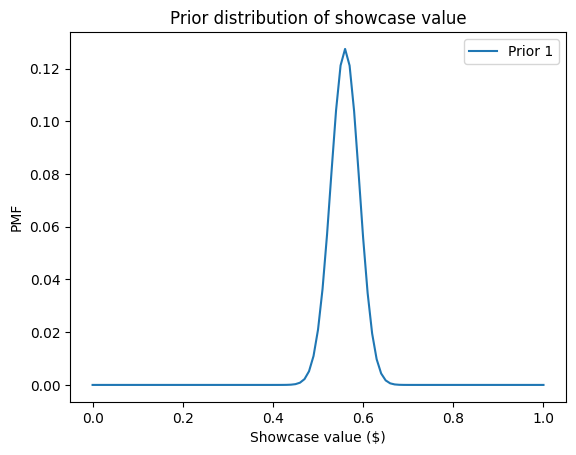

In [4]:
import matplotlib.pyplot as plt

posterior.plot(label = 'Prior 1')
plt.xlabel('Showcase value ($)')
plt.ylabel('PMF')
plt.title('Prior distribution of showcase value')
plt.legend()
plt.show()

In [5]:
print(posterior.mean(), 
    posterior.credible_interval(0.9))

0.5595238095238095 [0.51 0.61]


The prior mean was 0.5. The posterior mean is 0.56. So it seems that the data is evidence that the coin is biased. But, it's not that simple...

## Evidence

Consider the hypothetical from 'Oliver's Blood' from earlier:

- The data are considered in favor of hypothesis A if the data are more likely under A than the alternative B.

$$ P(D|A)>P(D|B) $$

Additionally, we can quantify the strength of the evidence by computing the ratio of these likelihoods (know as the Bayes Factor), often denoted K:

$$ K = \frac {P(D|A)} {P(D|B)} $$

In [6]:
# compute probablility

k = 140
n = 250

like_fair = binom.pmf(k, n, p = 0.5)
like_fair

np.float64(0.008357181724918191)

In [7]:
# if the coin is biased, what is the probability of the data?

# define biased as 56%

like_biased = binom.pmf(k, n, p = 0.56)
like_biased

np.float64(0.050778159595183524)

In [8]:
# produce K factor

K = like_biased / like_fair
K

np.float64(6.075990838368492)

The data are about 6 times more likely if the coin is biased than if the coin is fair. 

But.... We used the data to define the hypothesis. To be fair, we should define biased before we see the data. 

## Uniformly Distributed Bias

Suppose that 'biased' means that the probability is anything except 50% and all other values are equally likely. Here is how we would represent that definition:

In [9]:
biased_uniform = uniform.copy()
biased_uniform[0.5] = 0
biased_uniform.normalize()

np.int64(100)

In [10]:
# compute total probability by computing conditional probability of each x value

xs = biased_uniform.qs
likelihood = binom.pmf(k, n, xs)

In [11]:
# multipy the prior proababilities and add up the products

like_uniform = np.sum(biased_uniform * likelihood)
like_uniform

np.float64(0.0039004919277707386)

In [12]:
# bayes factor of data with new 'biased' def

K = like_fair / like_uniform
K

np.float64(2.142596851801357)

To get a sense of how strong the data is, we can apply Baye's rule:

If the prior probability is 50% that the coin is biased, the prior odds are 1, so the posterior is odds are about 2.1 to 1 and the posterior probability is about 68%. 

In [13]:
prior_odds = 1
posterior_odds = prior_odds * K
posterior_odds

np.float64(2.142596851801357)

In [14]:
def prob(o):
    return o / (o + 1)

In [15]:
posterior_probability = prob(posterior_odds)
posterior_probability

np.float64(0.6817918278551086)

Author notes that evidence that moves the needle from 50% to 68% is not very strong. 

In [16]:
# new biased def

ramp_up = np.arange(50)
ramp_down = np.arange(50, -1, -1)
a = np.append(ramp_up, ramp_down)

In [17]:
triangle = Pmf(a, xs, name = 'triangle')
triangle.normalize()

np.int64(2500)

In [18]:
# remove 50% as a possible value

biased_triangle = triangle.copy()
biased_triangle[0.5] = 0
biased_triangle.normalize()

np.float64(0.98)

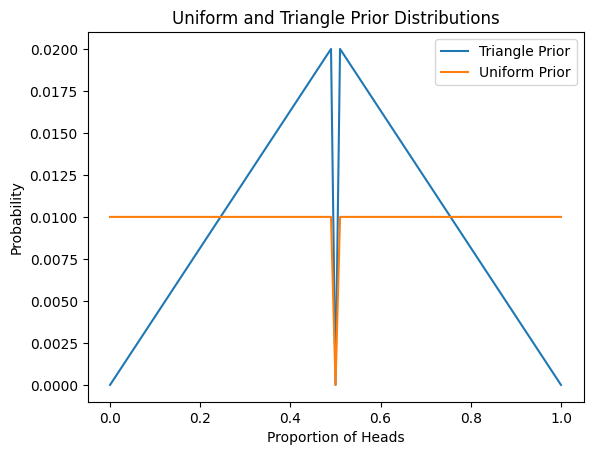

In [19]:
biased_triangle.plot(label = 'Triangle Prior')
biased_uniform.plot(label = 'Uniform Prior')
plt.xlabel('Proportion of Heads')
plt.ylabel('Probability')
plt.title('Uniform and Triangle Prior Distributions')
plt.legend()
plt.show()

In [20]:
# compute total probability under this bias definition

xs = biased_triangle.qs
likelihood = binom.pmf(k, n, xs)

In [21]:
like_triangle = np.sum(biased_triangle * likelihood)
like_triangle

np.float64(0.006981325464857886)

In [22]:
# bayes factor of data with new 'biased' def

K = like_fair / like_triangle
K

np.float64(1.1970766535647128)

In [23]:
prior_odds = 1
posterior_odds = prior_odds * K
posterior_odds

np.float64(1.1970766535647128)

In [24]:
posterior_probability = prob(posterior_odds)
posterior_probability

np.float64(0.5448497446015277)

Even less strong!!

## Bayesian Hypothesis Testing

So far this chapter, we have been doing Bayesian hypothesis testing as opposed to statistical hypothesis teseting. 

In statistical hypothesis testing, we compute a p-value to determine if the results are statistically significant. 

The Bayesian alternative is the K factor which summarizes the strength of the evidence in favor of one hypothesis or another. 

Some people think it is better to report K than a posterior probability because K does not depend of a prior probability. But as we saw in this example, K often depends of the definition of the hypothesis which can be just as controversial as the prior. 

Bayesian hypothesis testing is the author's preference because it measures the strength of the evidence on a continuum rather than a binary determination. But it doesn't answer fundamental questions that are perhaps more meaningful:

- Prediction: Based on what we know, what can we expect?
- Decision-making: Can we use those predictions to make better decisions?

Let's try it out. 

## Bayesian Bandits

Slot machines are often called one-armed bandits because they have a handle like an arm and can make money like bandits. The Bayesian Bandit strategy is named thus because it has the ability to solve problems in a similar fashion. 

Imagine you have a bunch of slot machines with all different unkown likelihoods to win. You know nothing about them so you start with the same prior for all of them. After some time playing, however, you gather evidence about their win-rates and make decisions about which machines you want to play based on the likelihood of sucess. 

## Prior Beliefs

In [25]:
# start with a unifor prior

xs = np.linspace(0, 1, 101)
prior = Pmf(1, xs)
prior.normalize()

np.int64(101)

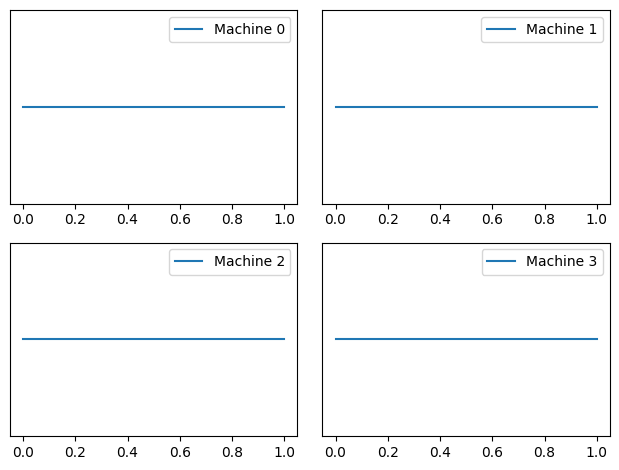

In [26]:
beliefs = [prior.copy() for i in range(4)]

def plot(beliefs, **options):
    for i, b in enumerate(beliefs):
        plt.subplot(2, 2, i + 1)
        b.plot(label=f"Machine {i}")
        plt.xlabel("")
        plt.yticks([])
        plt.legend()
    plt.tight_layout()

plot(beliefs)

## Update

In [27]:
# each time we play, we get an outcome and update our beliefs

likelihood = {
    'W': xs, 
    'L': 1 - xs
}

def update(pmf, data):
    """ Update probability of winning"""
    pmf *= likelihood[data]
    pmf.normalize()

In [28]:
# play the machine 10 times

bandit = prior.copy()

for outcome in 'WLLLLLLLLLLL':
    update(bandit, outcome)

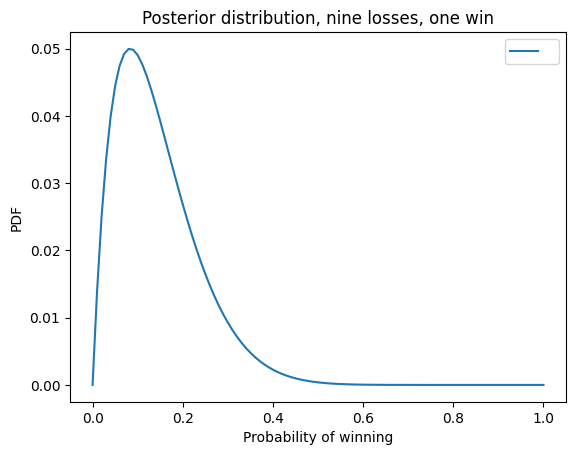

In [29]:
bandit.plot(label = ' ')
plt.xlabel('Probability of winning')
plt.ylabel('PDF')
plt.title('Posterior distribution, nine losses, one win')
plt.legend()
plt.show()

## Multiple Bandits

In [58]:
# suppose we have four machines 

actual_probs = [0.1, 0.2, 0.3, 0.4]

In [59]:
from collections import Counter

# count how many times we've played each machine
counter = Counter()

def play(i):
    """ play machine i. 

    i: index of machine to play

    returns: string 'W' or 'L'
    """
    counter[i] += 1
    p = actual_probs[i]
    if np.random.random() < p:
        return 'W'
    else: 
        return 'L'

In [60]:
for i in range(4):
    for _ in range (10):
        outcome = play(i)
        update(beliefs[i], outcome)

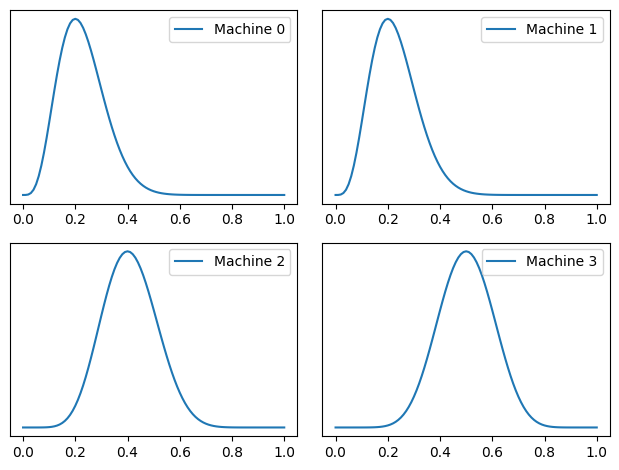

In [61]:
plot(beliefs)

In [62]:
import pandas as pd

def summarize_beliefs(beliefs):
    rows = []
    for i, b in enumerate(beliefs):
        ci = b.credible_interval(0.9)
        rows.append({
            'Actual P(win)': actual_probs[i],
            'Posterior mean': round(b.mean(), 3),
            'Credible interval': np.round(ci, 3),
        })
    return pd.DataFrame(rows)

summarize_beliefs(beliefs)

,Actual P(win),Posterior mean,Credible interval
0,0.1,0.227,"[0.1, 0.38]"
1,0.2,0.227,"[0.1, 0.38]"
2,0.3,0.409,"[0.25, 0.58]"
3,0.4,0.500,"[0.33, 0.67]"


## Explote and Exploit

In order to optimize our playing, we could continue to gather enough data to know very confidently (imagine we are still at 10 tries per machine) that one machine has the best probability of winning. 

Or, we could try something called Thompson sampling where we choose which machine randomly, but where the probablility of choosing the machine is proportional to the probability that it is the best. 

In [63]:
samples = np.array([b.choice(1000)
                    for b in beliefs])

samples.shape

(4, 1000)

In [64]:
indices = np.argmax(samples, axis = 0)
indices.shape

(1000,)

In [65]:
pmf = Pmf.from_seq(indices)
pmf

,probs
0,0.015
1,0.011
2,0.266
3,0.708


In [66]:
pmf.choice()

array([1])

Thats a lot of work for a single value. If we draw a single random value from each posterior distribution and select the machine that yeilds the highest value, it turns out that we'll select each machine in porportion to it's probability of superiority. 

In [67]:
def choose(beliefs):
    """ Use Thompson sampling to choose a machine. 

    Draws a single sample from each distribution. 

    returns: index of the machine that yielded the highest value"""
    ps = [b.choice() for b in beliefs]
    return np.argmax(ps)

In [68]:
choose(beliefs)

np.int64(3)

## The Strategy

Put it all together: the following function chooses a machine, plays once, and updates beliefs:

In [69]:
def choose_play_update(beliefs):
    """ choose machine, play it, update beliefs"""

    # choose machine
    machine = choose(beliefs)

    # play it
    outcome = play(machine)

    # update beliefs
    update(beliefs[machine], outcome)

In [85]:
# test with a fresh set of beliefs and empty counter

beliefs = [prior.copy() for i in range(4)]
counter = Counter()

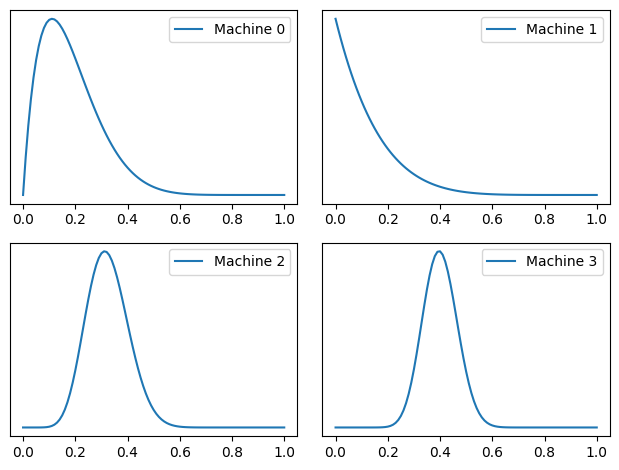

In [86]:
num_plays = 100

for i in range(num_plays):
    choose_play_update(beliefs)

plot(beliefs)

In [87]:
summarize_beliefs(beliefs)

,Actual P(win),Posterior mean,Credible interval
0,0.1,0.182,"[0.04, 0.39]"
1,0.2,0.121,"[0.0, 0.34]"
2,0.3,0.324,"[0.2, 0.46]"
3,0.4,0.400,"[0.29, 0.51]"


In [88]:
counter

Counter({np.int64(3): 53, np.int64(2): 32, np.int64(0): 9, np.int64(1): 6})